# Accessible Heatmaps

This notebook is a standalone teaching resource for creating accessible heatmaps with Matplotlib and describing it with MatplotAlt.

## What this graph is used for

Heatmaps represent matrix values, correlations, intensity or magnitude, and other structured comparisons.

## How to make it more accessible

For accessibility, use a colorblind-friendly colormap, label rows and columns with semantic names, add a descriptive title, and provide a labeled color scale explaining what the colors encode. Readable tick labels and careful rotation can also improve interpretation.

## Setup

This notebook requires `matplotlib` and `matplotalt`; the heatmap notebook also uses `numpy`. If MatplotAlt is not installed, install it in your Python environment with `pip install matplotalt`.


### MatplotAlt description levels used in this notebook

The notebook generates descriptions at all four description levels using MatplotAlt:

- **Level 1:** axes and visual encodings such as color.
- **Level 2:** Level 1 plus statistics about the data.
- **Level 3:** Level 2 plus trends and relationships/correlation where supported.
- **Level 4:** broader contextual description. MatplotAlt's documentation indicates that Level 4 is available through its API/VLM functions, so this notebook uses `show_with_api_alt` for Level 4 and reads the API key from the `OPENAI_API_KEY` environment variable.

For Levels 1–3, the notebook uses the rule-based `show_with_alt` function. For Level 4, set an `OPENAI_API_KEY` in the environment before running the description cell.


In [1]:
import os
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from matplotalt import show_with_alt, show_with_api_alt

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")


def show_all_description_levels(build_plot, 
                                chart_type=None,
                                max_rule_based_level=3,
):
    """Plot the figure and display MatplotAlt descriptions at Levels 1–4."""

    # MatplotAlt's rule-based descriptions support Levels 1–3.
    for level in range(1, max_rule_based_level + 1):
        plt.close("all")
        build_plot()
        display(Markdown(f"#### Level {level} description"))
        kwargs = {
            "desc_level": level, 
            "methods": ["markdown"],
        }
        if chart_type is not None:
            kwargs["chart_type"] = chart_type
        show_with_alt(**kwargs)

    # Level 4 uses MatplotAlt's API/VLM description function.
    plt.close("all")
    display(Markdown("#### Level 4 description"))
    if OPENAI_API_KEY:
        build_plot()
        kwargs = {
            "methods": ["markdown"],
            "use_starter_alt_in_prompt": True,
        }
        if chart_type is not None:
            kwargs["chart_type"] = chart_type
        show_with_api_alt(OPENAI_API_KEY, **kwargs)
    else:
        display(Markdown(
            "**Level 4 was not generated because `OPENAI_API_KEY` is not set.** "
            "Set that environment variable and rerun this cell to generate the broader-context "
            "Level 4 description with MatplotAlt."
        ))


## Accessible example

The code below showcases an accessibility-aware example of a heatmap plot also presented in the Guidelines document.

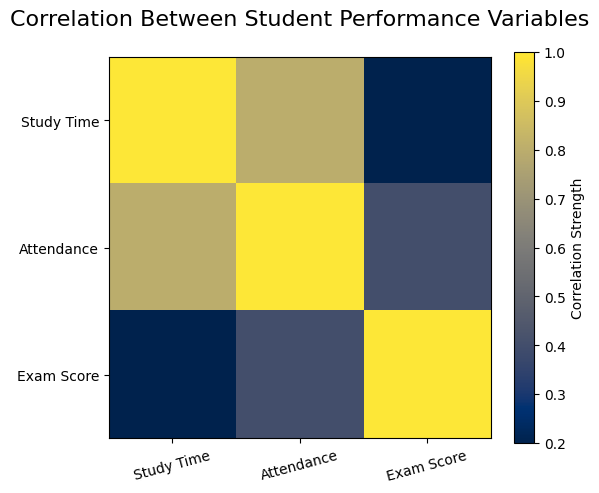

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

correlation_matrix = np.array([
    [1.0, 0.8, 0.2],
    [0.8, 1.0, 0.4],
    [0.2, 0.4, 1.0]
])

feature_names = ["Study Time", "Attendance", "Exam Score"]

fig, ax = plt.subplots(figsize=(6, 5))

heatmap = ax.pcolormesh(
    correlation_matrix,
    cmap="cividis",
    shading="auto",
)

ax.set_xticks(
    np.arange(len(feature_names)) + 0.5,
    feature_names,
    rotation=15
)
ax.set_yticks(np.arange(len(feature_names)) + 0.5, feature_names)
ax.invert_yaxis()

ax.set_title("Correlation Between Student Performance Variables\n", fontsize=16)
fig.colorbar(heatmap, ax=ax, label="Correlation Strength")
plt.tight_layout()

plt.show()


### MatplotAlt descriptions for the worked example

The next cell recreates the same graph and generates Levels 1–3 with `show_with_alt`. It generates Level 4 with `show_with_api_alt` when `OPENAI_API_KEY` is available.

#### Level 1 description

A 3x3 heatmap titled 'correlation between student performance variables'. The x-axis ranges from study time to exam score using a categorical scale, the y-axis ranges from study time to exam score using a categorical scale, and correlation strength is plotted on the z-axis from 0.2 to 1 using a linear scale.

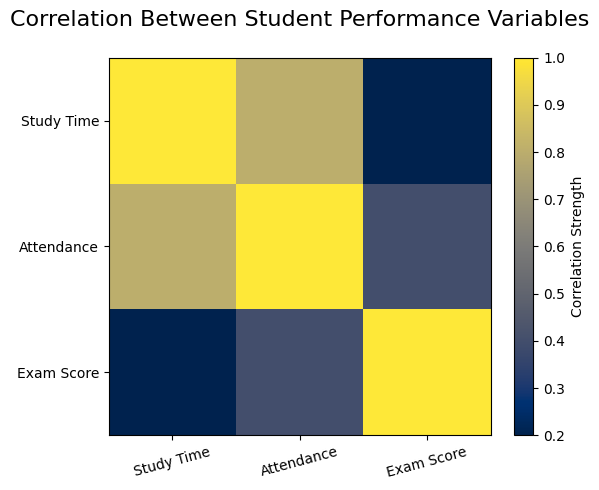

#### Level 2 description

A 3x3 heatmap titled 'correlation between student performance variables'. The x-axis ranges from study time to exam score using a categorical scale, the y-axis ranges from study time to exam score using a categorical scale, and correlation strength is plotted on the z-axis from 0.2 to 1 using a linear scale. The data has a minimum value of z=0.2 at (2, 0), a maximum value of z=1 at (0, 0), and an average of z=0.6444.

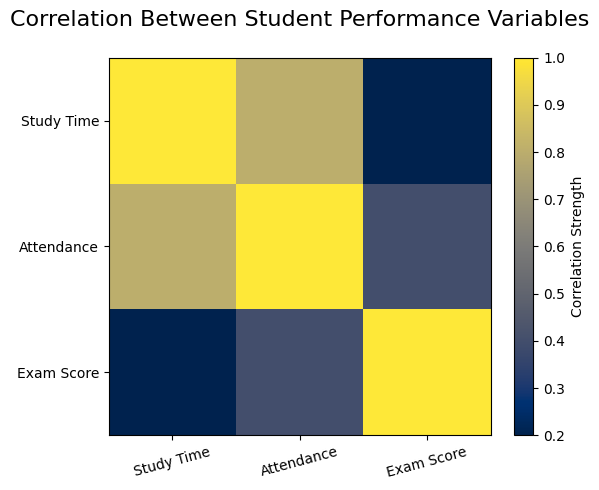

#### Level 3 description

A 3x3 heatmap titled 'correlation between student performance variables'. The x-axis ranges from study time to exam score using a categorical scale, the y-axis ranges from study time to exam score using a categorical scale, and correlation strength is plotted on the z-axis from 0.2 to 1 using a linear scale. The data has a minimum value of z=0.2 at (2, 0), a maximum value of z=1 at (0, 0), and an average of z=0.6444.

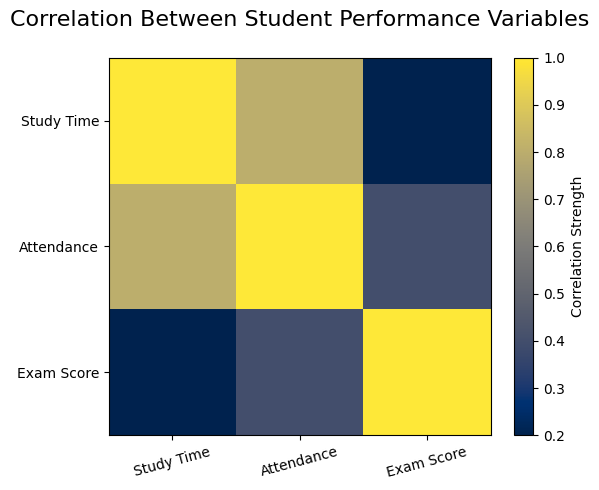

#### Level 4 description

**Level 4 was not generated because `OPENAI_API_KEY` is not set.** Set that environment variable and rerun this cell to generate the broader-context Level 4 description with MatplotAlt.

In [9]:
def build_example_plot():
    import numpy as np

    correlation_matrix = np.array([
        [1.0, 0.8, 0.2],
        [0.8, 1.0, 0.4],
        [0.2, 0.4, 1.0]
    ])

    feature_names = ["Study Time", "Attendance", "Exam Score"]

    fig, ax = plt.subplots(figsize=(6, 5))

    heatmap = ax.pcolormesh(
        correlation_matrix,
        cmap="cividis",
        shading="auto",
    )

    ax.set_xticks(
        np.arange(len(feature_names)) + 0.5,
        feature_names,
        rotation=15
    )
    ax.set_yticks(np.arange(len(feature_names)) + 0.5, feature_names)
    ax.invert_yaxis()

    ax.set_title("Correlation Between Student Performance Variables\n", fontsize=16)
    fig.colorbar(heatmap, ax=ax, label="Correlation Strength")
    plt.tight_layout()


show_all_description_levels(
    build_example_plot, 
    chart_type="heatmap",
)


## Reusable accessible template

Replace the placeholder data and text with your own values. Keep the descriptive labels, meaningful title, readable text, high-contrast/redundant encodings where relevant, and the other accessibility features shown.

In [ ]:
import numpy as np

# Replace the placeholder matrix, names, and text below with your own values.
matrix_values = np.array([
    [1.0, 0.6, 0.3],
    [0.6, 1.0, 0.5],
    [0.3, 0.5, 1.0]
])

row_and_column_names = ["Variable A", "Variable B", "Variable C"]
graph_title = "Descriptive title for the matrix relationship"
colorbar_label = "Magnitude or relationship strength"


def build_accessible_heatmap():
    plt.figure(figsize=(6, 5))

    heatmap = plt.imshow(
        matrix_values,
        cmap="cividis"
    )

    plt.xticks(
        range(len(row_and_column_names)),
        row_and_column_names,
        rotation=15
    )
    plt.yticks(
        range(len(row_and_column_names)),
        row_and_column_names
    )

    plt.title(graph_title, fontsize=16)
    plt.colorbar(heatmap, label=colorbar_label)
    plt.tight_layout()


build_accessible_heatmap()
plt.show()


### MatplotAlt descriptions for the template graph

Run the next cell after adapting the placeholders. It generates all four description levels in the same way as the shown example.

In [ ]:
show_all_description_levels(build_accessible_heatmap, chart_type="heatmap")